# Projektna naloga - napovedovanje PM10 z rekurentnimi nevronskimi mrezami

Cilj: cim natancneje napovedati naslednjo vrednost parametra **PM10** (kvaliteta zraka)
iz multivariatne casovne vrste meritev.

Vsebina notebooka:
1. Obdelava in procesiranje podatkov (manjkajoce vrednosti, izkrivljenost, inzeniring in izbira znacilnic, normalizacija).
2. Priprava casovnih oken in delitev na ucno (prvo leto) in testno obdobje.
3. Izgradnja in ucenje rekurentne nevronske mreze (LSTM).
4. Ovrednotenje (MAE, MAPE, MSE, EVS) in izris napovedi.
5. Serializacija modela in scalerjev za spletno storitev.

In [1]:
# Uvoz knjiznic + skupni modul za predprocesiranje (uporabljen tudi v storitvi)
import numpy as np, pandas as pd, pickle, warnings
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             explained_variance_score, mean_absolute_percentage_error)
import prep_projekt as pp
warnings.filterwarnings('ignore')
np.random.seed(1234); tf.random.set_seed(1234)
print('TF', tf.__version__)

TF 2.18.1


## 1. Nalaganje in pregled podatkov

In [2]:
# Nalaganje surovih podatkov in osnovni pregled
df = pd.read_csv('dataset_E408.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)
print('Oblika:', df.shape)
print('Obdobje:', df['datetime'].min(), '->', df['datetime'].max())
print('Frekvenca: urne meritve')
df.head()

Oblika: (14100, 10)
Obdobje: 2024-05-02 20:00:00 -> 2025-12-11 07:00:00
Frekvenca: urne meritve


,datetime,PM10,PM2.5,temperature,rain,pressure,precipitation,wind_speed,clouds,wind_direction
0,2024-05-02 20:00:00,6.0,3.0,14.0,1.5,1007.0,76.0,6.0,oblačno,NaN
1,2024-05-02 21:00:00,4.0,2.0,12.0,0.5,1007.0,81.0,1.0,oblačno,NaN
2,2024-05-02 22:00:00,6.0,2.0,12.0,0.8,1007.0,88.0,2.0,oblačno,NaN
3,2024-05-02 23:00:00,6.0,3.0,11.0,0.0,1007.0,76.0,1.0,pretežno oblačno,NaN
4,2024-05-03 00:00:00,6.0,3.0,10.0,0.0,1007.0,85.0,1.0,pretežno oblačno,NaN


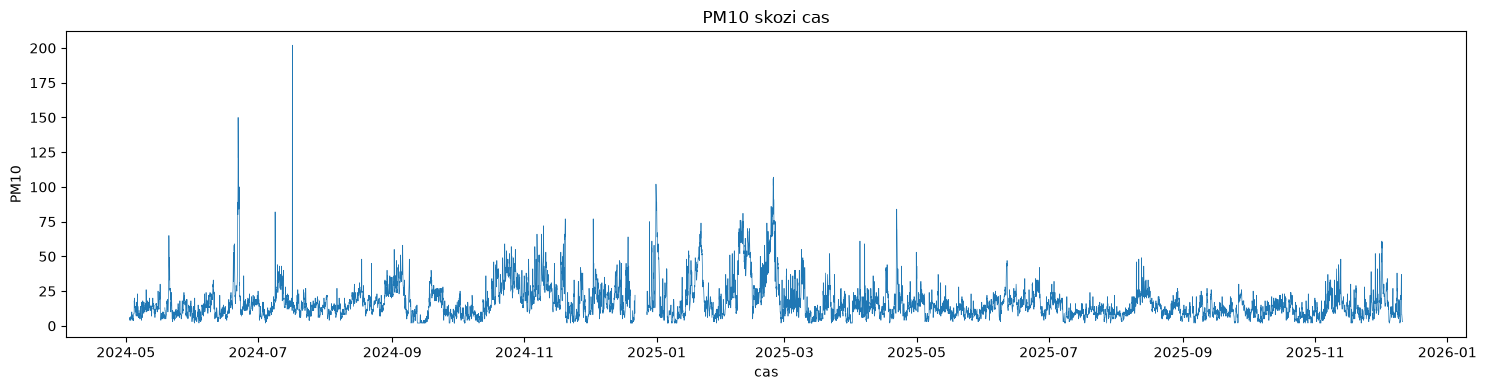

In [3]:
# Izris ciljne spremenljivke PM10 skozi cas
plt.figure(figsize=(15,4))
plt.plot(df['datetime'], df['PM10'], linewidth=0.5)
plt.title('PM10 skozi cas'); plt.xlabel('cas'); plt.ylabel('PM10'); plt.tight_layout(); plt.show()

In [4]:
# Pregled manjkajocih vrednosti
print('Manjkajoce vrednosti po stolpcih:')
print(df.isnull().sum())

Manjkajoce vrednosti po stolpcih:
datetime             0
PM10               179
PM2.5              179
temperature        215
rain               215
pressure           230
precipitation      215
wind_speed         215
clouds             215
wind_direction    6932
dtype: int64


In [5]:
# Pregled IZKRIVLJENOSTI numericnih znacilnic (kateri stolpci so desno-izkrivljeni)
num = ['PM10','PM2.5','temperature','rain','pressure','precipitation','wind_speed']
print('Izkrivljenost (skewness):')
print(df[num].skew().sort_values(ascending=False))

Izkrivljenost (skewness):
rain             10.792388
PM2.5             2.757816
PM10              2.583012
wind_speed        1.564877
pressure          0.215347
temperature      -0.090537
precipitation    -0.580322
dtype: float64


## 2. Obdelava podatkov

Vsa obdelava je zbrana v modulu `prep_projekt.build_features`, ki:
- **zapolni manjkajoce vrednosti** (casovna interpolacija + mediana),
- **kodira kategoricne** znacilnice (`clouds` ordinalno, `wind_direction` v `sin/cos`),
- doda **casovne ciklicne znacilnice** (ura, dan, mesec, vikend),
- **popravi izkrivljenost** desno-izkrivljenih znacilnic (`log1p`: PM10, PM2.5, rain, wind_speed).

In [6]:
# Gradnja znacilnic prek skupnega modula
X_df, y_ser = pp.build_features(df)
print('Znacilnice:', list(X_df.columns))
print('Oblika X:', X_df.shape, ' brez NaN:', X_df.isnull().sum().sum()==0)
X_df.head()

Znacilnice: ['PM10_l', 'PM2.5_l', 'temperature', 'pressure', 'precipitation', 'rain_l', 'wind_speed_l', 'clouds_ord', 'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos', 'dow', 'month', 'is_weekend']
Oblika X: (14100, 15)  brez NaN: True


,PM10_l,PM2.5_l,temperature,pressure,precipitation,rain_l,wind_speed_l,clouds_ord,wd_sin,wd_cos,hour_sin,hour_cos,dow,month,is_weekend
0,1.945910,1.386294,14.0,1007.0,76.0,0.916291,1.945910,3.0,0.0,0.0,-0.866025,0.500000,3.0,5.0,0.0
1,1.609438,1.098612,12.0,1007.0,81.0,0.405465,0.693147,3.0,0.0,0.0,-0.707107,0.707107,3.0,5.0,0.0
2,1.945910,1.098612,12.0,1007.0,88.0,0.587787,1.098612,3.0,0.0,0.0,-0.500000,0.866025,3.0,5.0,0.0
3,1.945910,1.386294,11.0,1007.0,76.0,0.000000,0.693147,2.0,0.0,0.0,-0.258819,0.965926,3.0,5.0,0.0
4,1.945910,1.386294,10.0,1007.0,85.0,0.000000,0.693147,2.0,0.0,0.0,0.000000,1.000000,4.0,5.0,0.0


## 3. Izbira znacilnic

Pogledamo korelacijo posameznih znacilnic s ciljno vrednostjo PM10 (po log1p transformaciji).

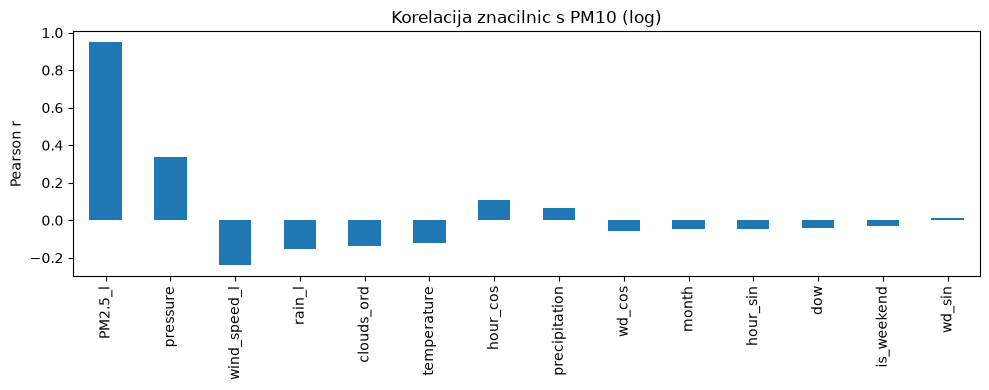

PM2.5_l          0.947566
pressure         0.338855
wind_speed_l    -0.239264
rain_l          -0.154319
clouds_ord      -0.139694
temperature     -0.123191
hour_cos         0.109654
precipitation    0.066671
wd_cos          -0.055158
month           -0.047626
hour_sin        -0.046213
dow             -0.038980
is_weekend      -0.028009
wd_sin           0.009544
dtype: float64

Opomba: najmocneje koreliran je PM2.5; ohranimo vse znacilnice, saj rekurentna mreza sama izlusci uporabne vzorce, mnozica znacilnic pa je obvladljiva (15).


In [7]:
# Korelacija znacilnic s ciljno log-vrednostjo PM10 (PM10_l)
kor = X_df.corrwith(X_df['PM10_l']).drop('PM10_l').sort_values(key=abs, ascending=False)
plt.figure(figsize=(10,4))
kor.plot(kind='bar'); plt.title('Korelacija znacilnic s PM10 (log)'); plt.ylabel('Pearson r')
plt.tight_layout(); plt.show()
print(kor)
print('\nOpomba: najmocneje koreliran je PM2.5; ohranimo vse znacilnice, saj rekurentna '
      'mreza sama izlusci uporabne vzorce, mnozica znacilnic pa je obvladljiva (15).')

## 4. Delitev na ucno/testno obdobje in normalizacija

Model ucimo na **prvem letu meritev** (prvih 8760 urnih meritev), preostanek je testno obdobje.
Normalizacija (`StandardScaler`) je naucena **samo na ucnem obdobju** (brez puscanja informacij).

In [8]:
# Delitev: prvo leto = ucno obdobje
TRAIN_LEN = 8760           # 365 dni * 24 ur
WINDOW = 24                # velikost okna = 1 dan (<= 1 teden, kot zahteva navodilo)

# scalerji naucimo SAMO na ucnem delu
feat_scaler = StandardScaler().fit(X_df.values[:TRAIN_LEN])
targ_scaler = StandardScaler().fit(y_ser.values[:TRAIN_LEN].reshape(-1,1))

X_scaled = feat_scaler.transform(X_df.values)
y_scaled = targ_scaler.transform(y_ser.values.reshape(-1,1)).flatten()

In [9]:
# Gradnja multivariatnih oken in delitev na ucno/testno glede na indeks cilja
Xw, yw = pp.make_windows(X_scaled, y_scaled, WINDOW)
# indeks cilja okna i je (i + WINDOW); meja med ucno in testno mnozico je TRAIN_LEN
meja = TRAIN_LEN - WINDOW
X_train, y_train = Xw[:meja], yw[:meja]
X_test,  y_test  = Xw[meja:], yw[meja:]
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape,  'y_test :', y_test.shape)

X_train: (8736, 24, 15) y_train: (8736,)
X_test : (5340, 24, 15) y_test : (5340,)


## 5. Izgradnja in ucenje modela (LSTM)

Arhitektura: dva sloja LSTM (64 in 32 enot) + Dropout + polno povezana sloja.
Hiperparametre (velikost mreze, dropout, ucno stopnjo) smo izbrali eksperimentalno;
uporabimo `EarlyStopping` za preprecitev preprileganja.

In [10]:
# Gradnja in ucenje rekurentne nevronske mreze
model = Sequential([
    Input(shape=(WINDOW, X_train.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
es = EarlyStopping(patience=8, restore_best_weights=True)
hist = model.fit(X_train, y_train, validation_split=0.15,
                 epochs=60, batch_size=64, callbacks=[es], verbose=0)
print('Koncni val_loss:', round(hist.history['val_loss'][-1],4), '| epoh:', len(hist.history['loss']))

Koncni val_loss: 0.1137 | epoh: 40


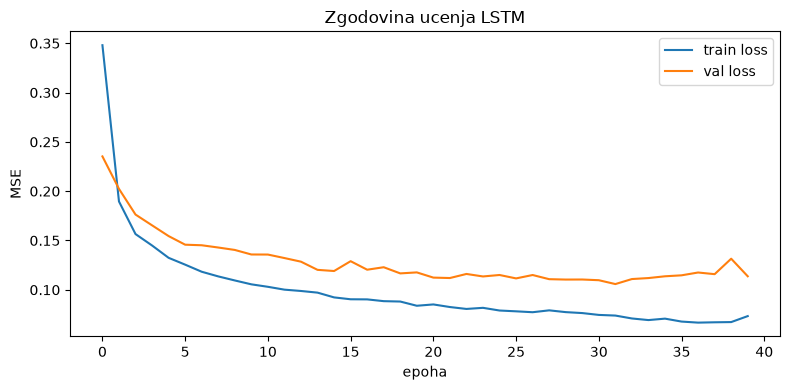

In [11]:
# Izris zgodovine ucenja
plt.figure(figsize=(8,4))
plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='val loss')
plt.title('Zgodovina ucenja LSTM'); plt.xlabel('epoha'); plt.ylabel('MSE'); plt.legend()
plt.tight_layout(); plt.show()

## 6. Ovrednotenje na testnih podatkih

Napovedi in prave vrednosti pretvorimo nazaj v izvirno skalo PM10 ter izracunamo
metrike **MAE, MAPE, MSE, EVS**.

In [12]:
# Napoved + inverzna standardizacija + metrike
y_pred_s = model.predict(X_test, verbose=0).flatten()
y_pred = targ_scaler.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
y_true = targ_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

print('--- Metrike na testnih podatkih ---')
print(f'MAE : {mean_absolute_error(y_true, y_pred):.3f}')
print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred)*100:.2f} %')
print(f'MSE : {mean_squared_error(y_true, y_pred):.3f}')
print(f'EVS : {explained_variance_score(y_true, y_pred):.4f}')

--- Metrike na testnih podatkih ---
MAE : 2.524
MAPE: 22.02 %
MSE : 13.948
EVS : 0.7192


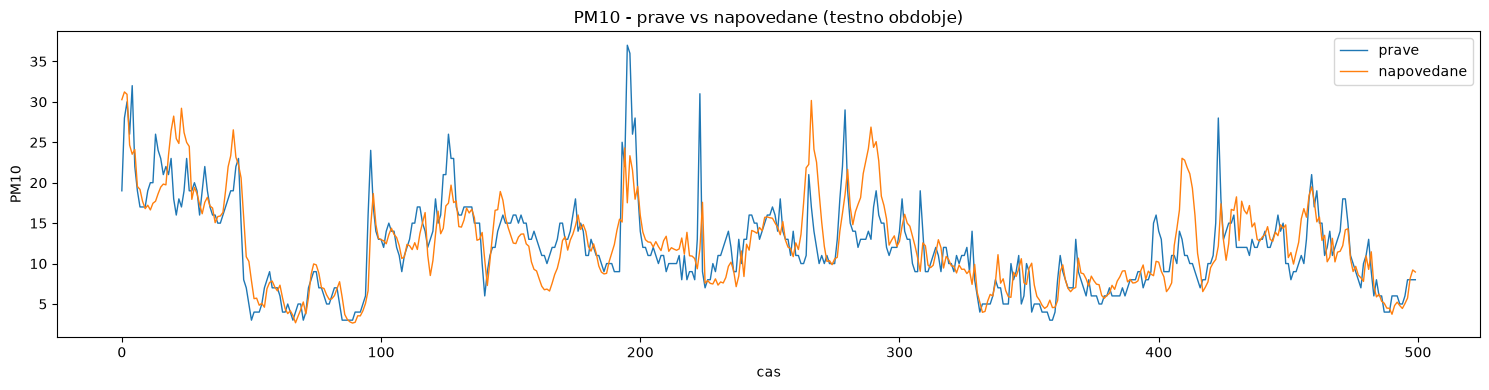

In [13]:
# Graf pravih in napovedanih vrednosti PM10 (prvih 500 testnih tock)
plt.figure(figsize=(15,4))
plt.plot(y_true[:500], label='prave', linewidth=1)
plt.plot(y_pred[:500], label='napovedane', linewidth=1)
plt.title('PM10 - prave vs napovedane (testno obdobje)'); plt.xlabel('cas'); plt.ylabel('PM10'); plt.legend()
plt.tight_layout(); plt.show()

## 7. Serializacija za spletno storitev

Shranimo model in oba scalerja ter konfiguracijo (velikost okna, vrstni red znacilnic).

In [14]:
# Shranjevanje modela in scalerjev v mapo service/models
import os
os.makedirs('service/models', exist_ok=True)
model.save('service/models/model_pm10.keras')
with open('service/models/scalers_pm10.pkl','wb') as f:
    pickle.dump({'feat_scaler': feat_scaler, 'targ_scaler': targ_scaler,
                 'window': WINDOW, 'features': pp.FEATURES}, f)
print('Shranjeno: service/models/model_pm10.keras, scalers_pm10.pkl')

Shranjeno: service/models/model_pm10.keras, scalers_pm10.pkl
